# PyTorch Basic

In [1]:
import numpy as np
import torch

In [2]:
torch.__version__

'2.6.0+cu124'

# torch.Tensor

- torch 의 다차원 배열 객체

https://pytorch.org/docs/stable/torch.html#tensors

In [3]:
np.arange(9)

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [4]:
tensor = torch.arange(9)
tensor

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [5]:
type(tensor)

torch.Tensor

In [6]:
tensor.shape

torch.Size([9])

In [7]:
tensor.numpy()

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [8]:
tensor.reshape(3, 3)

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [9]:
randoms = torch.rand((3, 3))
randoms

tensor([[0.3227, 0.8450, 0.9645],
        [0.5157, 0.6582, 0.4801],
        [0.3655, 0.7708, 0.4667]])

In [10]:
randoms.dtype

torch.float32

In [11]:
randoms.size()  # numpy 와는 다름!

torch.Size([3, 3])

In [12]:
torch.zeros((3, 3))

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [13]:
torch.zeros_like(randoms) # randoms 와 shape 이 동일한 0 으로 구성된 tensor

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [14]:
torch.ones((3, 3))

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

# Operations

In [15]:
tensor

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [16]:
tensor * 3

tensor([ 0,  3,  6,  9, 12, 15, 18, 21, 24])

In [17]:
tensor = tensor.reshape(3, 3)
tensor

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [18]:
tensor + tensor

tensor([[ 0,  2,  4],
        [ 6,  8, 10],
        [12, 14, 16]])

In [19]:
tensor + 10

tensor([[10, 11, 12],
        [13, 14, 15],
        [16, 17, 18]])

In [20]:
torch.add(tensor, 10)

tensor([[10, 11, 12],
        [13, 14, 15],
        [16, 17, 18]])

# Tensor Views

https://pytorch.org/docs/stable/tensor_view.html#tensor-views

- 기존 tensor 의 데이터는 공유하지만, shape 이 다른 view 제공
- view() 는 reshape() 거의 같다..
- view() 는 사실, 훨씬 오래전부터 있어왔다.   (사실 reshape() 를 더 추천한다.)
- ※ 단, 공식 예제에선 View 를 사용함.

In [21]:
range_nums = torch.arange(9).reshape(3, 3)
range_nums

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [22]:
range_nums.view(1, 9)

tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8]])

In [23]:
range_nums.reshape(1, 9)

tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8]])

In [24]:
range_nums.view(-1)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])

# slice & index

In [25]:
nums = torch.arange(9).reshape(3, 3)
nums

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [26]:
nums[1]

tensor([3, 4, 5])

In [27]:
nums[1, 1]

tensor(4)

In [28]:
nums[1:]

tensor([[3, 4, 5],
        [6, 7, 8]])

In [29]:
nums[1:, 1:]

tensor([[4, 5],
        [7, 8]])

# Compile

In [30]:
arr = np.array([1, 1, 1])
arr

array([1, 1, 1])

In [31]:
arr_torch = torch.from_numpy(arr)
arr_torch

tensor([1, 1, 1])

In [32]:
arr_torch.dtype  # int64

torch.int64

In [33]:
arr_torch.float()

tensor([1., 1., 1.])

In [34]:
# GPU detect 하기

In [35]:
torch.cuda.is_available()

True

In [36]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [37]:
# Tensor 를 특정 device 에 compile
# to(device)

arr_torch.to(device)

tensor([1, 1, 1], device='cuda:0')

In [38]:
arr_torch.device

device(type='cpu')

### PyTorch 와 Tensorflow 에서 compile 차이점(요약)

| **특징**              | **PyTorch `torch.compile`**                                   | **TensorFlow `model.compile`**                      |
|-----------------------|-------------------------------------------------------------|---------------------------------------------------|
| **목적**              | 실행 속도 최적화                                              | 학습 설정 (손실 함수, 옵티마이저 등 지정)             |
| **언제 사용?**        | 학습 및 추론 속도를 개선하려고 할 때                              | 모델을 학습하기 전에 필요한 설정을 정의할 때          |
| **비유**              | 효율적으로 요리하는 셰프가 되도록 준비                          | 어떤 재료와 조리법으로 요리할지 결정하는 단계         |
| **주요 입력**         | 모델 객체                                                   | 옵티마이저, 손실 함수, 평가지표 등                   |
| **결과**              | 더 빠른 실행 가능                                              | 학습 가능한 상태의 모델 생성                        |

---

### 요약
- **PyTorch `torch.compile`**: 속도 최적화를 위한 기술.
- **TensorFlow `model.compile`**: 학습을 시작하기 전에 필요한 설정.

둘 다 이름은 비슷하지만 역할은 완전히 다릅니다!

# AutoGrad
'기울기' 를 주어 학습이 되게 하는 것.

In [39]:
x = torch.ones(2, 2, requires_grad=True)
x

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)

In [40]:
x.grad  # 학습기울기,  처음에는 없다 None

In [41]:
y = x + 2
y

tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)

In [42]:
y.grad_fn

In [43]:
z = y * y * 3
z

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>)

In [44]:
out = z.mean()
out

tensor(27., grad_fn=<MeanBackward0>)

In [45]:
out.backward()  # back-propagation(역전파) 수행! -> 하면 x 의 기울기를 구할수 있다.

In [46]:
x.grad   # x 의 학습 기울기가 계산되어 있다!!!

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])

In [47]:
x.requires_grad

True

In [48]:
(x ** 2).requires_grad

True

In [49]:
# Tensorflow : Define and Run 방식
# PyTorch : Define By Run 방식

# PyTorch 에선 train mode 와 test mode 가 있다.
# '학습모드(train mode)' 에서는 기울기 구하는게 가능하지만
# '테스트모드(test mode)' 에서는 이기능을 꺼야 겠죠
#    -> no_grad() 사용

In [50]:
with torch.no_grad():
  print((x ** 2).requires_grad)  # no_grad() 안에서는 False, 기울기를 구하지 않게 된다.
  #

False


In [51]:
# no_grad() 이면  기울기를 구하지 않게 됩니다.
# 따라서 batch, normalization dropout 들이 작동 안함
# 작동 속도는 train mode 일때보다 test mode 가 더 빠르겠죠.

# PyTorch Data Preprocess

In [52]:
import matplotlib.pyplot as plt

from torchvision import datasets, transforms


## DataLoader()
PyTorch 는 DataLoader() 사용하여 model 에 데이터 입력

In [53]:
batch_size = 32
test_batch_size = 32

In [54]:
save_dir = r'.'

In [55]:
# train loader
train_loader = torch.utils.data.DataLoader(
    dataset = datasets.FashionMNIST(
        save_dir,  # 저장할 디렉토리.   {save_dir}/FashionMNIST 에 다운로드
        train=True, # 학습용
        download=True,  # 없으면 다운로드.
        transform=transforms.Compose([  # 데이터 로딩시 필요현 변환(transform) (들)을 나열.
            transforms.ToTensor(),   # 데이터 다운 받은뒤 Tensor 로 변환.
            transforms.Normalize(mean=(0.5,), std=(0.5,)) # 평균값 0.5, std 0.5 로 스케일링 변환
        ]),
    ),
    batch_size = batch_size,  # 배치 사이즈
    shuffle=True,
)

In [56]:
# test loader
test_loader = torch.utils.data.DataLoader(
    dataset = datasets.FashionMNIST(
        save_dir,  # 저장할 디렉토리.   {save_dir}/FashionMNIST 에 다운로드
        train=False, # 학습모드로 사용하는 데이터가 아니다!
        transform=transforms.Compose([  # 데이터 로딩시 필요현 변환(transform) (들)을 나열.
            transforms.ToTensor(),   # 데이터 다운 받은뒤 Tensor 로 변환.
            transforms.Normalize(mean=(0.5,), std=(0.5,)) # 평균값 0.5, std 0.5 로 스케일링 변환
        ]),
    ),
    batch_size = batch_size,  # 배치 사이즈
    shuffle=True,
)

## 데이터 확인

In [57]:
type(train_loader)
# DataLoader 객체 <-- iterable 하다
# batch 단위로 데이터 iteration.

torch.utils.data.dataloader.DataLoader

In [58]:
images, labels = next(iter(train_loader))  # 첫번째 batch

In [59]:
images.shape, labels.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [60]:
# TF (batch, height, width, channel)

# PyTorch( batch, channel, height, width)

↑ 뭔가 다르죠?


TensorFlow 에선 [32, 28, 28. 1]   즉 [batch size, height, width, channel] 이었습니다


PyTorch는 TensorFlow와 다르게 [Batch Size, Channel, Height, Width] 임을 명심해야함

만약 gray 가 아니라 rgb 였으면 [32, 3, 28, 28] 이 되는 겁니다

In [61]:
# 첫번째 이미지
images[0].shape

torch.Size([1, 28, 28])

In [62]:
# 시각화를 위해서 axis 0 를 없애기
torch.squeeze(images[0]).shape

torch.Size([28, 28])

In [63]:
torch_image = torch.squeeze(images[0])
torch_image.shape

torch.Size([28, 28])

In [64]:
image = torch_image.numpy()
image.shape

(28, 28)

In [65]:
# 첫번째 label
label = labels[0].numpy()
label  # Dataloader 에서 shuffle 했기 때문에 random 인 상태.

array(2)

In [66]:
datasets.FashionMNIST.classes  # 레이블 명 확인

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [67]:
np.min(image), np.max(image)

(np.float32(-1.0), np.float32(1.0))

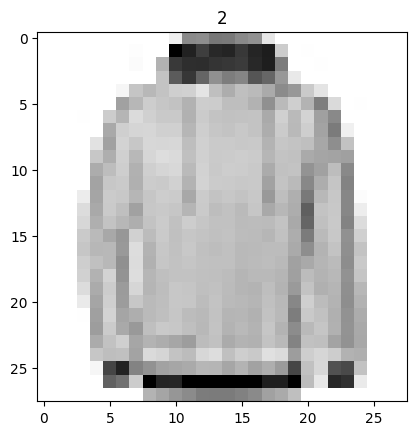

In [68]:
plt.title(label)
plt.imshow(image, cmap='gray_r')
plt.show()

# PyTorch 의 Layer

In [69]:
# train loader
train_loader = torch.utils.data.DataLoader(
    dataset = datasets.FashionMNIST(
        save_dir,  # 저장할 디렉토리.   {save_dir}/FashionMNIST 에 다운로드
        train=True, # 학습용
        download=True,  # 없으면 다운로드.
        transform=transforms.Compose([  # 데이터 로딩시 필요현 변환(transform) (들)을 나열.
            transforms.ToTensor(),   # 데이터 다운 받은뒤 Tensor 로 변환.
            # 현재는 모델학습이 목적이 아니라서 스케일링 생략.
        ]),
    ),
    batch_size = 1,  # 이번 예제 목적은 이미지 '하나하나' 를 레이어에 넣어 '확인'
    # shuffle=True,
)

In [70]:
# 첫번째 배치
image, label = next(iter(train_loader))

image.shape

torch.Size([1, 1, 28, 28])

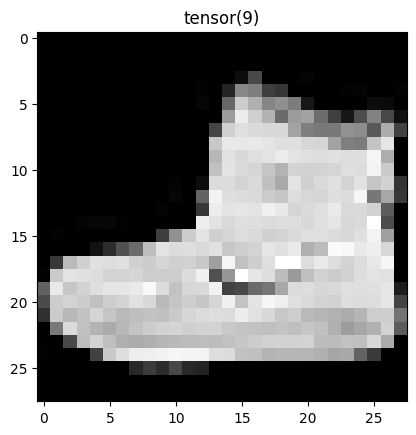

In [71]:
plt.imshow(image[0, 0, :, :], 'gray')
plt.title(label[0])
plt.show()

In [72]:
# PyTorch 에선 레이어를 쌓기 위해 다음과 같은 레이어 필요
import torch.nn as nn   # nn 레이어와
import torch.nn.functional as F  # F 레이어

In [73]:
# nn : 파라미터 있는 레이어
# F : 파라미터 없는 연산을 위한 레이어

## nn.Conv2D()
- in_channels: 받게 될 channel의 갯수
- out_channels: 보내고 싶은 channel의 갯수  
- kernel_size: 만들고 싶은 kernel(weights)의 사이즈

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html?highlight=conv2d#torch.nn.Conv2d

In [74]:
nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1)

Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))

In [75]:
# ↑ TensorFlow 에서 봤을때와 좀 다르죠.

#  TensorFlow 에선 out channel 만 나왔습니다.  (얼마나 내보낼 것인지, filters=값)
#  PyTorch 는 앞에서 몇개를 받을지도 지정해주어야 하는 것입니다. (in_channels)
#  위 이미지의 채널은 1 이었습니다'  >> torch.Size([1, 1, 28, 28])
#  그리고 이것을 20개로 내보냅니다 (out_channels)

#  kernel_size = 5   TensorFlow 때는 3x3 이었는데
# PyTorch 공식예제 에선 5x5 로 되어 있어서 5로 주었습니다.

# stride = 1

In [76]:
layer_conv1 = nn.Conv2d(1, 20, 5, 1).to(torch.device(device))
layer_conv1

Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))

In [77]:
# weight 꺼내보기
weight = layer_conv1.weight
weight.shape

torch.Size([20, 1, 5, 5])

In [78]:
# torch.Size([20, 1, 5, 5])
#  20개 filters x channel 1개 x height 5 x width 5

In [79]:
weight

Parameter containing:
tensor([[[[-0.0533, -0.1457, -0.1372, -0.0105, -0.1555],
          [ 0.1067,  0.0081,  0.1064,  0.1499,  0.1739],
          [ 0.0493,  0.0270, -0.1236,  0.1940, -0.0576],
          [-0.0602,  0.1487,  0.0868, -0.0789,  0.0954],
          [ 0.1832,  0.0218,  0.1367,  0.1543,  0.1574]]],


        [[[-0.0879,  0.1794, -0.1541,  0.0774,  0.1871],
          [ 0.1388, -0.0011,  0.1107, -0.1691, -0.0849],
          [-0.1299,  0.0888,  0.0913, -0.0379, -0.0314],
          [ 0.1852, -0.1420,  0.0750, -0.1560, -0.1292],
          [-0.0727,  0.0221, -0.1449,  0.0407,  0.0024]]],


        [[[-0.0025,  0.1834,  0.0727, -0.0734, -0.1781],
          [ 0.0971, -0.0262, -0.0714, -0.1182, -0.0748],
          [ 0.0130,  0.1542,  0.0432, -0.1288,  0.0136],
          [ 0.0572,  0.1953,  0.1934,  0.1078, -0.1264],
          [-0.1003, -0.0933,  0.0449,  0.1851,  0.1763]]],


        [[[-0.0640,  0.0802,  0.1981,  0.0003,  0.0560],
          [-0.0775, -0.0772,  0.1237,  0.0100,  0.1126

In [80]:
# weight.numpy()  # 에러

- 여기서 weight는 '학습 가능한 상태'이기 때문에 바로 numpy로 뽑아낼 수 없음
    - '학습 가능?' 유연한, 말랑말랑한 tensor..
- detach() method는 그래프에서 잠깐 빼서 gradient에 영향을 받지 않게 함

In [81]:
weight = weight.detach().cpu().numpy()
weight

array([[[[-0.05332294, -0.14570336, -0.13721775, -0.01054971,
          -0.15554865],
         [ 0.10672047,  0.00807993,  0.10635185,  0.14992736,
           0.17387748],
         [ 0.04934292,  0.02697604, -0.12359619,  0.19399999,
          -0.05756326],
         [-0.06015944,  0.14867488,  0.08684986, -0.07891107,
           0.0953727 ],
         [ 0.18323746,  0.02181306,  0.13669153,  0.15434356,
           0.1573826 ]]],


       [[[-0.08787572,  0.17942046, -0.15406612,  0.07741006,
           0.18706636],
         [ 0.13875459, -0.00107946,  0.1106803 , -0.16910549,
          -0.08488581],
         [-0.12994838,  0.0887712 ,  0.09133682, -0.03792708,
          -0.0313875 ],
         [ 0.18517272, -0.14202762,  0.07495601, -0.15603562,
          -0.1292285 ],
         [-0.07267511,  0.02213166, -0.14488037,  0.04065404,
           0.0024389 ]]],


       [[[-0.00247655,  0.18344407,  0.07268999, -0.07336605,
          -0.17814298],
         [ 0.09710696, -0.02620399, -0.0713521

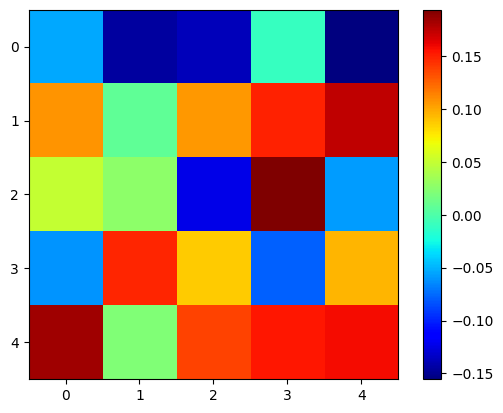

In [82]:
# 20개의 filter 중 첫번째 시각화
plt.imshow(weight[0, 0, :, :], 'jet')
plt.colorbar()
plt.show()

In [83]:
# output 시각화

In [84]:
# image 를 layer 에 넣어본다
# GPU 모델을 만든 경우 입력데이타도 GPU 데이터 이어야 합니다
output_data = layer_conv1(image if device == 'cpu' else image.cuda())

output_data.shape

torch.Size([1, 20, 24, 24])

In [85]:
output_data

tensor([[[[-0.1781, -0.1781, -0.1781,  ..., -0.1736, -0.1749, -0.1737],
          [-0.1781, -0.1781, -0.1781,  ..., -0.1705, -0.1612, -0.1626],
          [-0.1781, -0.1781, -0.1781,  ...,  0.0518,  0.0342, -0.0301],
          ...,
          [-0.1255, -0.1093, -0.0841,  ..., -0.0092,  0.0150, -0.0555],
          [-0.2108, -0.2032, -0.1221,  ..., -0.0595, -0.0754, -0.1740],
          [-0.3092, -0.2721, -0.2338,  ..., -0.3221, -0.3940, -0.3540]],

         [[ 0.0678,  0.0678,  0.0678,  ...,  0.0664,  0.0644,  0.0670],
          [ 0.0678,  0.0678,  0.0678,  ...,  0.0657,  0.0698,  0.0613],
          [ 0.0678,  0.0678,  0.0678,  ...,  0.0372,  0.0178,  0.0024],
          ...,
          [ 0.1460,  0.0889,  0.0684,  ...,  0.2119,  0.2202,  0.2540],
          [ 0.0383,  0.0862,  0.1193,  ...,  0.2047,  0.2095,  0.2113],
          [ 0.2151,  0.0998,  0.0557,  ...,  0.3179,  0.3080,  0.1734]],

         [[ 0.1783,  0.1783,  0.1783,  ...,  0.1808,  0.1774,  0.1789],
          [ 0.1783,  0.1783,  

In [86]:
output_data.data  # .data 만 추출.

tensor([[[[-0.1781, -0.1781, -0.1781,  ..., -0.1736, -0.1749, -0.1737],
          [-0.1781, -0.1781, -0.1781,  ..., -0.1705, -0.1612, -0.1626],
          [-0.1781, -0.1781, -0.1781,  ...,  0.0518,  0.0342, -0.0301],
          ...,
          [-0.1255, -0.1093, -0.0841,  ..., -0.0092,  0.0150, -0.0555],
          [-0.2108, -0.2032, -0.1221,  ..., -0.0595, -0.0754, -0.1740],
          [-0.3092, -0.2721, -0.2338,  ..., -0.3221, -0.3940, -0.3540]],

         [[ 0.0678,  0.0678,  0.0678,  ...,  0.0664,  0.0644,  0.0670],
          [ 0.0678,  0.0678,  0.0678,  ...,  0.0657,  0.0698,  0.0613],
          [ 0.0678,  0.0678,  0.0678,  ...,  0.0372,  0.0178,  0.0024],
          ...,
          [ 0.1460,  0.0889,  0.0684,  ...,  0.2119,  0.2202,  0.2540],
          [ 0.0383,  0.0862,  0.1193,  ...,  0.2047,  0.2095,  0.2113],
          [ 0.2151,  0.0998,  0.0557,  ...,  0.3179,  0.3080,  0.1734]],

         [[ 0.1783,  0.1783,  0.1783,  ...,  0.1808,  0.1774,  0.1789],
          [ 0.1783,  0.1783,  

In [87]:
output = output_data.data.cpu().numpy()
output

array([[[[-0.17806171, -0.17806171, -0.17806171, ..., -0.17357294,
          -0.17487776, -0.17368111],
         [-0.17806171, -0.17806171, -0.17806171, ..., -0.17051423,
          -0.16121602, -0.16255395],
         [-0.17806171, -0.17806171, -0.17806171, ...,  0.05177185,
           0.03416121, -0.03010073],
         ...,
         [-0.12550887, -0.10934389, -0.08406511, ..., -0.00917971,
           0.01497351, -0.05550042],
         [-0.21075955, -0.20315862, -0.12210306, ..., -0.05946487,
          -0.07543257, -0.17397493],
         [-0.30917925, -0.2721473 , -0.23376569, ..., -0.3221494 ,
          -0.3939885 , -0.35396296]],

        [[ 0.06783912,  0.06783912,  0.06783912, ...,  0.06635237,
           0.06442318,  0.06704202],
         [ 0.06783912,  0.06783912,  0.06783912, ...,  0.06570806,
           0.06980711,  0.06125523],
         [ 0.06783912,  0.06783912,  0.06783912, ...,  0.03719385,
           0.01782213,  0.00240228],
         ...,
         [ 0.14598069,  0.08888416

In [88]:
# 시각화를 위해 image 에서 numpy 배열 추출
image_arr = image.cpu().numpy()
image_arr.shape

(1, 1, 28, 28)

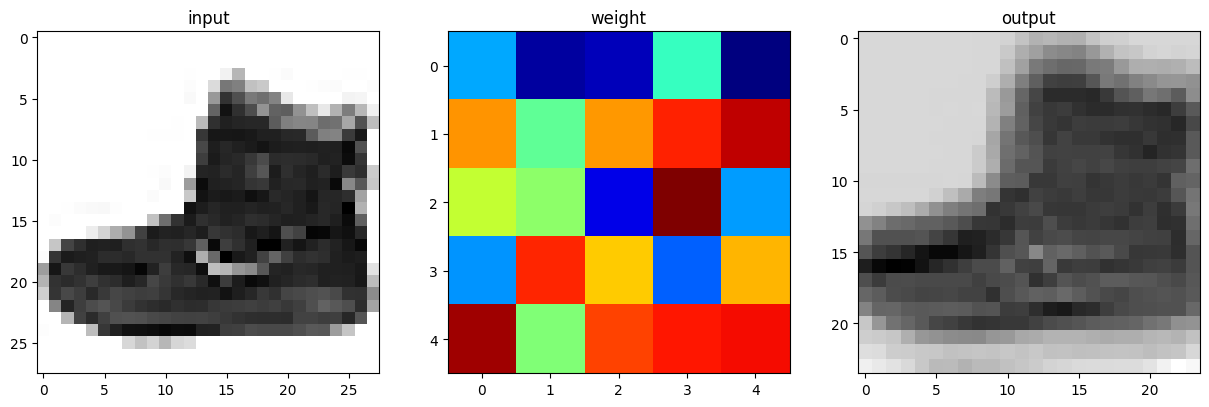

In [89]:
plt.figure(figsize=(15, 30))

plt.subplot(131)
plt.title('input')
plt.imshow(np.squeeze(image_arr), 'gray_r')

plt.subplot(132)
plt.title('weight')
plt.imshow(weight[0, 0, :, :], 'jet')

plt.subplot(133)
plt.title('output')
plt.imshow(output[0, 0, :, :], 'gray_r')


plt.show()

## F.max_pool2d()

In [90]:
pool = F.max_pool2d(image, kernel_size=2, stride=2)
pool.shape #  (1, 1, 14, 14) <- (1, 1, 28, 28)

torch.Size([1, 1, 14, 14])

In [91]:
pool_arr = pool.numpy()
pool_arr

array([[[[0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.00392157, 0.05098039, 0.28627452, 0.00392157,
          0.01568628, 0.        , 0.00392157, 0.00392157],
         [0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.02352941, 0.8       , 0.6901961 , 0.5647059 ,
          0.09019608, 0.01176471, 0.04705882, 0.03921569],
         [0.        , 0.        , 0.        , 0.        , 0.        ,
          0.00392157, 0.27058825, 0.9254902 , 0.85490197, 0.84705883,
          0.6313726 , 0.57254905, 0.5529412 , 0.6745098 ],
         [0.        , 0.        , 0.        , 0.        , 0.00392157,
          0.00392157, 0.78431374, 0.9098039 , 0.9137255 , 0.92156863,
          0.8784314 , 0.8784314 , 0.9607843 , 0.8980392 ],
     

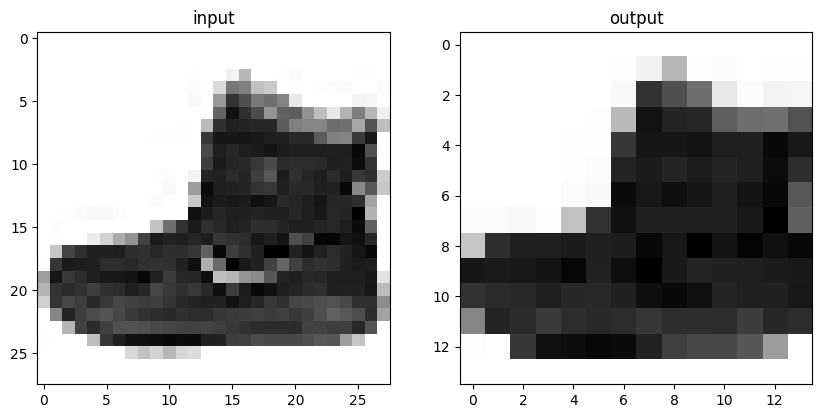

In [92]:
plt.figure(figsize=(10, 15))

plt.subplot(121)
plt.title('input')
plt.imshow(np.squeeze(image_arr), 'gray_r')

plt.subplot(122)
plt.title('output')
plt.imshow(np.squeeze(pool_arr), 'gray_r')


plt.show()

## nn.Linear()
- nn.Linear는 2d가 아닌 1d만 들어가기 때문에 .view() 1D로 펼쳐줘야함
- TensorFlow 처럼 Flatten 이라는 레이어가 따로 있는게 아니라서  
    - 우선, reshape 나 view 를 사용해서 펼쳐 준뒤, Linear() 에 넣어야 합니다

In [93]:
image.shape

torch.Size([1, 1, 28, 28])

In [94]:
flatten = image.view(-1, 28 * 28)
flatten.shape

torch.Size([1, 784])

In [95]:
lin = nn.Linear(in_features=784, out_features=10)(flatten)
lin.shape

torch.Size([1, 10])

In [96]:
lin

tensor([[ 0.3190,  0.4112, -0.0601, -0.2085, -0.0907, -0.6664,  0.1597, -0.3446,
          0.0413,  0.2492]], grad_fn=<AddmmBackward0>)

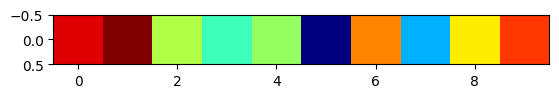

In [97]:
plt.imshow(lin.detach().numpy(), 'jet')
plt.show()

## F.softmax()

In [98]:
with torch.no_grad():
  flatten = image.view(1, 28 * 28)
  lin = nn.Linear(784, 10)(flatten)  # (1, 10)
  softmax = F.softmax(lin, dim=1)

In [99]:
softmax

tensor([[0.0869, 0.0970, 0.1013, 0.1395, 0.0852, 0.0899, 0.1587, 0.0828, 0.0866,
         0.0723]])

In [100]:
np.sum(softmax.numpy())

np.float32(1.0)

# Layer 쌓기

In [101]:
class Net(nn.Module):  # nn.Module 을 상속받아 모델의 layer 쌓기

  # 생성자 에는 '학습(train)' 이 가능한 것, 즉 weight 가 들어있는 레이어 정의
  # 위 예제코드에선 Conv 와 Linear 가 그런 레이어었댜.
  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(1, 20, 5, 1)
    self.conv2 = nn.Conv2d(20, 50, 5, 1)

    self.fc1 = nn.Linear(4 * 4 * 50, 500)
    self.fc2 = nn.Linear(500, 10)  # 최종 출력 10개 클래스

  def forward(self, x):   # x : 입력
    # 1. Feature extraction
    x = F.relu(self.conv1(x))  # Convolution 결과는 활성화 함수 relu 를 거쳐 출력.
    x = F.max_pool2d(x, 2, 2)
    x = F.relu(self.conv2(x))
    x = F.max_pool2d(x, 2, 2)

    # conv1 입력 (1, 28, 28) => conv1 => (20, 24, 24) => maxpool => (20, 12, 12)
    # conv2 입력 (20, 12, 12) => conv2 => (50, 8, 8) => maxpool => (50, 4, 4)
    # 위 결과를 펼쳐서 Linear 의 입력으로 전달

    # 2. Classification
    x = x.view(-1, 4 * 4 * 50)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)

    # 3. softmax
    return F.softmax(x, dim=1)



In [102]:
model = Net()  # 모델 생성!

In [103]:
result = model.forward(image)

result

tensor([[0.1036, 0.1010, 0.0928, 0.0970, 0.1023, 0.1002, 0.1025, 0.0985, 0.0993,
         0.1028]], grad_fn=<SoftmaxBackward0>)

In [104]:
model.conv1

Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))

In [105]:
model.conv1(image)

tensor([[[[-7.9920e-02, -7.9920e-02, -7.9920e-02,  ..., -8.0618e-02,
           -8.2963e-02, -8.3439e-02],
          [-7.9920e-02, -7.9920e-02, -7.9920e-02,  ..., -7.3475e-02,
           -7.1814e-02, -7.6019e-02],
          [-7.9920e-02, -7.9920e-02, -7.9920e-02,  ..., -1.6835e-01,
           -1.1112e-01, -1.3436e-01],
          ...,
          [ 3.4812e-02,  9.1134e-02,  2.5876e-01,  ...,  5.0559e-01,
            4.7534e-01,  4.5563e-01],
          [ 1.3641e-01,  3.2309e-02,  2.9023e-02,  ...,  2.9891e-01,
            3.5282e-01,  2.1424e-01],
          [ 1.2387e-02,  5.6583e-02,  1.1643e-01,  ...,  1.3378e-01,
            2.5128e-02, -1.0292e-01]],

         [[ 6.4993e-02,  6.4993e-02,  6.4993e-02,  ...,  6.6869e-02,
            6.5000e-02,  6.3715e-02],
          [ 6.4993e-02,  6.4993e-02,  6.4993e-02,  ...,  7.3307e-02,
            7.5337e-02,  7.4504e-02],
          [ 6.4993e-02,  6.4993e-02,  6.4993e-02,  ...,  5.6200e-02,
            1.1176e-01,  7.9068e-02],
          ...,
     

# Optimization

In [106]:
seed = 1   # shuffle 시 동일하게 섞기 => DataLoader

batch_size = 64
test_batch_size = 64

no_cuda = False

In [107]:
use_cuda = not no_cuda and torch.cuda.is_available()  # GPU 사용 여부
use_cuda

True

In [108]:
device

'cuda'

In [109]:
save_dir

'.'

## Preprocess

In [110]:
torch.manual_seed(seed)  # 랜덤 seed

train_loader = torch.utils.data.DataLoader(
    dataset = datasets.FashionMNIST(
        save_dir,
        train=True,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.1307,), std=(0.3081,))
        ]),
    ),
    batch_size = batch_size,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    dataset = datasets.FashionMNIST(
        save_dir,
        train=False,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.1307,), std=(0.3081,))
        ]),
    ),
    batch_size = test_batch_size,
    shuffle=True,
)

## Optimization
- Model 과 Optimization 설정

In [111]:
model = Net().to(device)  # model 생성하여 device 에 컴파일 해준다

In [112]:
# 학습 parameter 들 확인 가능
params = list(model.parameters())
params

[Parameter containing:
 tensor([[[[ 0.1031, -0.0883, -0.0388,  0.0939, -0.1883],
           [ 0.1199, -0.0411,  0.1017,  0.0278, -0.0245],
           [ 0.0555,  0.0099,  0.0730, -0.0779, -0.0146],
           [-0.0180,  0.0290, -0.0008,  0.1748,  0.0622],
           [-0.0745, -0.1208, -0.0335, -0.0863, -0.0641]]],
 
 
         [[[ 0.0096,  0.1192,  0.1087, -0.1955,  0.1240],
           [ 0.0559,  0.1897,  0.1320, -0.1822, -0.1902],
           [-0.0965,  0.1756, -0.0333,  0.0856, -0.0929],
           [ 0.1962, -0.0846,  0.1500,  0.0024, -0.1054],
           [ 0.1028, -0.1062,  0.0588, -0.0578, -0.0219]]],
 
 
         [[[-0.1923, -0.0954,  0.1085, -0.0486,  0.1992],
           [ 0.1603, -0.0094, -0.1335,  0.1218,  0.0621],
           [-0.1293,  0.1299,  0.1214,  0.1774, -0.1121],
           [-0.0329, -0.0039,  0.0292, -0.1518, -0.1419],
           [ 0.1088, -0.0469,  0.0977,  0.0114,  0.0657]]],
 
 
         [[[ 0.0440,  0.0727,  0.0991, -0.1852,  0.1007],
           [-0.1406, -0.1509,  

In [113]:
len(params)  # 8개의 Tensor 객체

# 학습 가능한 레이어 4개 + 4 (각 레이어마다 bias)

8

In [114]:
for param in params:
  print(param.size())

torch.Size([20, 1, 5, 5])
torch.Size([20])
torch.Size([50, 20, 5, 5])
torch.Size([50])
torch.Size([500, 800])
torch.Size([500])
torch.Size([10, 500])
torch.Size([10])


In [115]:
# torch.Size([20, 1, 5, 5]) <-- conv1 의 weight size
# torch.Size([20])          <-- conv1 의 bias (out channel 의 개수만큼!)
# torch.Size([50, 20, 5, 5])<-- conv2 의 weight size
# torch.Size([50])          <-- conv2 의 bias (out channel 의 개수만큼!)
# torch.Size([500, 800])    <-- fc1 의 weight size (out, in)
# torch.Size([500])         <-- fc1 의 bias  (out channel 의 개수만큼!)
# torch.Size([10, 500])     <-- fc2 의 weight size (out, in)
# torch.Size([10])          <-- fc2 의 bias  (out channel 의 개수만큼!)

In [116]:
# Optimizer 설정
import torch.optim as optim

In [117]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.5)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.5
    nesterov: False
    weight_decay: 0
)

## before training
- Model 이 train 할수 있도록 train mode 변환

In [118]:
model.train()  # 학습하기전에 train mode로 전환

Net(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)

In [119]:
# train mode (학습) ↔ evaluation mode (테스트, 예측)
# train mode 했다가 evalutaion mode 했다가   다시 train mode 로 돌아올때에도 .train() 을 해주어야 합니다

In [120]:
# 모델에 입력하기 위한 첫 batch 추출
data, target = next(iter(train_loader))  # 64개의 데이터

In [121]:
data.shape, target.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [122]:
# 추출한 batch 데이터도 device 에 compile
data, target = data.to(device), target.to(device)

In [123]:
# gradients 를 clear
# 학습하기 전에 Optimizer 를 clear해주어야 합니다.
# zero_grad() : gradient 를 clear 해서 새로운 최적값 을 찾기 위한 준비

In [124]:
optimizer.zero_grad()

In [125]:
# 준비한 데이터를 model 에 input 으로 입력하여 output 획득

output = model(data)  # 이건 '예측' 하는 동작 아니다 (현재 train mode!)
                    # 이 output 으로 loss 값 계산해야 한다!

In [126]:
output.shape

torch.Size([64, 10])

In [127]:
# Loss function
# Negative Log-Likelihood Loss(Nll) 라는 loss function 사용
loss = F.nll_loss(output, target)
loss

tensor(-0.1017, device='cuda:0', grad_fn=<NllLossBackward0>)

In [128]:
# back propagation 을 통해 gradients 를 계산
loss.backward()  # 기울기 계산!

In [129]:
# 기울기 계산후 Optimizer 에 업데이트 해주어야 한다.
# => paramete update
#    step(): 순방향 -> loss -> 역전파 -> 업데이트

optimizer.step()

이상이 '학습' 의 "1 스텝"입니다
- train 모드 변환
- 데이터 넣어주고
- 기울기 clear
- model 에 데이터 넣고
- loss 계산하고
- back propagation 하여 gradient 계산하고
- parameter 업데이트


## Training
위의 optimization 과정을 반복하여 학습

In [130]:
# hyper param 설정
epochs = 10

log_interval = 100  # 학습진행 중간중간에 로그를 확인하기 위해 몇 step 마다 로그 출력할지 결정

In [131]:
for epoch in range(1, epochs + 1):
  # 1. train 모드 전환
  model.train()

  # 2. batch 단위로 모델에 입력하고 학습 진행
  for batch_idx, (data, target) in enumerate(train_loader):
    # 3. 데이터를 device 에 compile
    data, target = data.to(device), target.to(device)
    # 4. 기울기 clear
    optimizer.zero_grad()

    #5. model 에 데이터 입력
    output = model(data)

    #6. loss 계산
    loss = F.nll_loss(output, target)

    #7. back propagation 하여 gradient 계산
    loss.backward()

    #8. parameter 업데이트
    optimizer.step()

    # 중간 중간에 로그 확인
    if batch_idx % log_interval == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
          epoch,
          batch_idx * len(data),
          len(train_loader.dataset),
          100 * batch_idx / len(train_loader),
          loss.item()  # loss 값
      ))

Train Epoch: 1 [0/60000 (0%)]	Loss: -0.099121
Train Epoch: 1 [6400/60000 (11%)]	Loss: -0.101983
Train Epoch: 1 [12800/60000 (21%)]	Loss: -0.101461
Train Epoch: 1 [19200/60000 (32%)]	Loss: -0.103422
Train Epoch: 1 [25600/60000 (43%)]	Loss: -0.101230
Train Epoch: 1 [32000/60000 (53%)]	Loss: -0.107429
Train Epoch: 1 [38400/60000 (64%)]	Loss: -0.105432
Train Epoch: 1 [44800/60000 (75%)]	Loss: -0.105198
Train Epoch: 1 [51200/60000 (85%)]	Loss: -0.113052
Train Epoch: 1 [57600/60000 (96%)]	Loss: -0.111110
Train Epoch: 2 [0/60000 (0%)]	Loss: -0.110279
Train Epoch: 2 [6400/60000 (11%)]	Loss: -0.108291
Train Epoch: 2 [12800/60000 (21%)]	Loss: -0.114458
Train Epoch: 2 [19200/60000 (32%)]	Loss: -0.109788
Train Epoch: 2 [25600/60000 (43%)]	Loss: -0.134763
Train Epoch: 2 [32000/60000 (53%)]	Loss: -0.117909
Train Epoch: 2 [38400/60000 (64%)]	Loss: -0.130139
Train Epoch: 2 [44800/60000 (75%)]	Loss: -0.147302
Train Epoch: 2 [51200/60000 (85%)]	Loss: -0.152975
Train Epoch: 2 [57600/60000 (96%)]	Loss: -0

# Evaluation

- 앞에서 model.train() 모드로 변한 것처럼 평가 할 때는 model.eval()로 설정
    - Batch Normalization이나 Drop Out 같은 Layer들을 잠금

In [132]:
model.eval()  # evaluation 모드 전환

Net(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)

In [133]:
# batch 하나를 evaluate
correct = 0
test_loss = 0  # 손실값 계산 (누적)

with torch.no_grad():
    # evaluation 에선  batch normalization 이나 drop out 같은 것들을 잠금
    # no_grad() 는 back propagation 이나 gradient 등의 계산을 꺼서 memory usage 를 줄이고 속도 높임
    # 테스트 모드일때는 이를 꺼주는 것이 좋다!

    # 테스트데이터에서 batch 하나 꺼내기
    data, target = next(iter(test_loader))
    data, target = data.to(device), target.to(device)
    output = model(data)

    # loss 계산.  no_grad라서 weight 업데이트 용이 아닐, 순수하게 손실값 계산용.
    test_loss += F.nll_loss(output, target, reduction='sum').item()

    pred = output.argmax(dim=1, keepdim=True)
            #  제일 강한 인덱스를 구함.  즉 컴이 계산한 정답 예측값 꺼냄.
            # keepdim=True : output 과 pred 의 dimension 유지

    correct = pred.eq(target.view_as(pred)).sum().item()  # pred 와 target 이 얼마나 같은가 판정
        # pred.eq(target.view_as(pred))  <-- 여기는 True / False 값 나옴
        #  .sum() 그것들을 다 더함.
        # .item() 값을 꺼내 담음


In [134]:
test_loss

-35.3048095703125

In [135]:
correct   # 한개 의 batch (64장의 이미지) 중 맞춘 개수 .

37

In [136]:
# evaluation (완성)

model.eval()

test_loss = 0
correct = 0

with torch.no_grad():
  for data, target in test_loader:  # test 의 모든 batch 돌려본다
    data, target = data.to(device), target.to(device)
    output = model(data)
    test_loss += F.nll_loss(output, target, reduction='sum').item()
    pred = output.argmax(dim=1, keepdim=True)
    correct += pred.eq(target.view_as(pred)).sum().item()

test_loss /= len(test_loader.dataset)  # loss 의 평균값

print('Test set : Average Loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss,
    correct,
    len(test_loader.dataset),
    100.0 * correct / len(test_loader.dataset)
))


Test set : Average Loss: -0.5979, Accuracy: 6152/10000 (62%)



# Training + Evaluation

In [137]:
for epoch in range(1, epochs + 1):
  # Train Mode
  model.train()

  for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()

    if batch_idx % log_interval == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
          epoch,
          batch_idx * len(data),
          len(train_loader.dataset),
          100 * batch_idx / len(train_loader),
          loss.item()  # loss 값
      ))

  # Eval Mode
  model.eval()

  test_loss = 0
  correct = 0

  with torch.no_grad():
    for data, target in test_loader:  # test 의 모든 batch 돌려본다
      data, target = data.to(device), target.to(device)
      output = model(data)
      test_loss += F.nll_loss(output, target, reduction='sum').item()
      pred = output.argmax(dim=1, keepdim=True)
      correct += pred.eq(target.view_as(pred)).sum().item()

  test_loss /= len(test_loader.dataset)  # loss 의 평균값

  print('Test set : Average Loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
      test_loss,
      correct,
      len(test_loader.dataset),
      100.0 * correct / len(test_loader.dataset)
  ))

Train Epoch: 1 [0/60000 (0%)]	Loss: -0.587787
Train Epoch: 1 [6400/60000 (11%)]	Loss: -0.605016
Train Epoch: 1 [12800/60000 (21%)]	Loss: -0.578669
Train Epoch: 1 [19200/60000 (32%)]	Loss: -0.620328
Train Epoch: 1 [25600/60000 (43%)]	Loss: -0.618060
Train Epoch: 1 [32000/60000 (53%)]	Loss: -0.595314
Train Epoch: 1 [38400/60000 (64%)]	Loss: -0.562909
Train Epoch: 1 [44800/60000 (75%)]	Loss: -0.499759
Train Epoch: 1 [51200/60000 (85%)]	Loss: -0.534320
Train Epoch: 1 [57600/60000 (96%)]	Loss: -0.592180
Test set : Average Loss: -0.6052, Accuracy: 6225/10000 (62%)

Train Epoch: 2 [0/60000 (0%)]	Loss: -0.691003
Train Epoch: 2 [6400/60000 (11%)]	Loss: -0.489114
Train Epoch: 2 [12800/60000 (21%)]	Loss: -0.601562
Train Epoch: 2 [19200/60000 (32%)]	Loss: -0.581560
Train Epoch: 2 [25600/60000 (43%)]	Loss: -0.597068
Train Epoch: 2 [32000/60000 (53%)]	Loss: -0.634870
Train Epoch: 2 [38400/60000 (64%)]	Loss: -0.545101
Train Epoch: 2 [44800/60000 (75%)]	Loss: -0.630084
Train Epoch: 2 [51200/60000 (85%

# 학습모델 저장하기

In [138]:
import os
save_path = os.path.join(save_dir, 'FashionMNIST.pth')
torch.save(model.state_dict(), save_path)

# 저장한 모델 불러오기

In [139]:
model = None

In [140]:
model = Net().to(device)
model.load_state_dict(torch.load(save_path))

<All keys matched successfully>

# 실제 데이터 적용 (예측하기)

In [141]:
base_path = r'/content/drive/MyDrive/DATA_SET/mnist_fashion'

In [142]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [143]:
import glob
img_paths = glob.glob(os.path.join(base_path, 'img_*.*'))
img_paths

['/content/drive/MyDrive/DATA_SET/mnist_fashion/img_ankle_boots.jpg',
 '/content/drive/MyDrive/DATA_SET/mnist_fashion/img_coat.jpg',
 '/content/drive/MyDrive/DATA_SET/mnist_fashion/img_pants.png',
 '/content/drive/MyDrive/DATA_SET/mnist_fashion/img_sandal.png',
 '/content/drive/MyDrive/DATA_SET/mnist_fashion/img_shirt.jpg']

In [144]:
from PIL import Image
import PIL.ImageOps as ops

In [145]:
def predict(file_path):
  img = Image.open(file_path)
  mono8img = img.convert('L')
  invImg = ops.invert(mono8img)
  resizeImg = invImg.resize((28, 28))
  # torch 에서의 입력 shape 로 변환
  data_arr = np.array(resizeImg).reshape(1, 1, 28, 28)
  tensor = torch.Tensor(data_arr)  # Tensor 로 변환
  transformed = transforms.Normalize((0.1307,), (0.3081,))(tensor)

  output = model(transformed.to(device))
  pred = output.argmax(dim=1, keepdim=True)

  return pred.item()

In [146]:
datasets.FashionMNIST.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [147]:
for img_path in img_paths:
  print(img_path, '->', datasets.FashionMNIST.classes[predict(img_path)])

/content/drive/MyDrive/DATA_SET/mnist_fashion/img_ankle_boots.jpg -> Ankle boot
/content/drive/MyDrive/DATA_SET/mnist_fashion/img_coat.jpg -> Coat
/content/drive/MyDrive/DATA_SET/mnist_fashion/img_pants.png -> Trouser
/content/drive/MyDrive/DATA_SET/mnist_fashion/img_sandal.png -> Bag
/content/drive/MyDrive/DATA_SET/mnist_fashion/img_shirt.jpg -> T-shirt/top


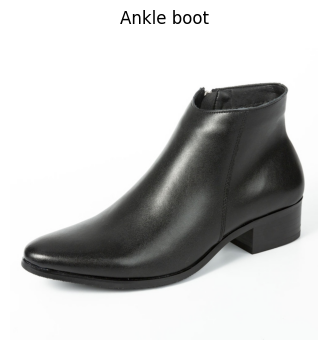

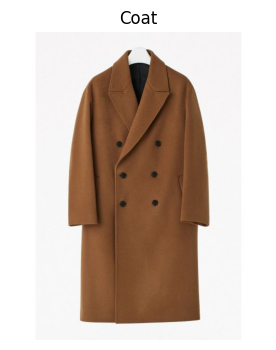

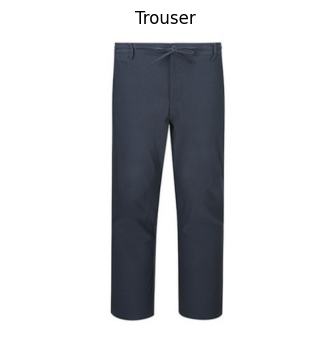

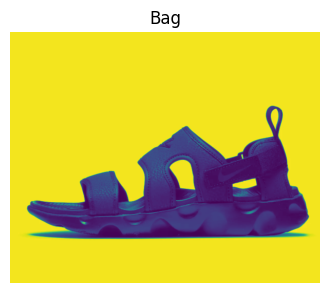

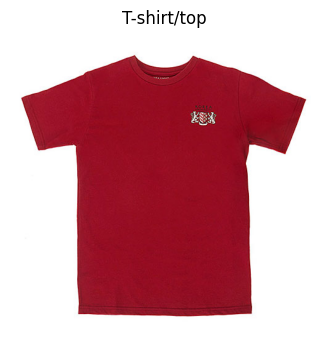

In [148]:
for img_path in img_paths:
  fig, ax = plt.subplots(1, 1, figsize=(4, 4))
  ax.axis('off')
  ax.set_title(datasets.FashionMNIST.classes[predict(img_path)])
  arr = plt.imread(img_path)
  plt.imshow(arr)
